# ⛭ Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nflreadpy as nfl

pd.set_option("display.width", 180)

/Users/dwang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
raw = nfl.load_player_stats([2024])
weekly = raw.to_pandas()
print(weekly.columns.tolist())

['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'season', 'week', 'season_type', 'team', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions', 'pacr', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'racr', 'target_share', 'air_yards_share', 'wopr', 'special_teams_tds', 'def_tackles_solo', 'def_tackles_with_assist', 'def_tackle_assists', 'def_tackles_for_loss'

In [11]:
# Define common helper functions

def print_player(df, full_name):
  return df[df['last_name, first_name'] == full_name]

In [1]:
import pandas as pd

batting_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1bTKGlowoa6BVkHgzQKuW107anXydXXzf")
pitching_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1B4N42kzC-UsMrN3chLWENnV6IcjeHG0d")

print("BATTING COLUMNS:")
print(batting_df.columns.tolist())

print("\nPITCHING COLUMNS:")
print(pitching_df.columns.tolist())

/Users/dwang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


BATTING COLUMNS:
['last_name, first_name', 'player_id', 'year', 'home_run', 'batting_avg', 'on_base_percent', 'on_base_plus_slg', 'b_gnd_into_dp']

PITCHING COLUMNS:
['last_name, first_name', 'player_id', 'year', 'p_formatted_ip', 'hit', 'walk', 'k_percent', 'bb_percent', 'babip', 'p_era', 'p_gnd_into_dp', 'barrel_batted_rate', 'hard_hit_percent']


## Load Batter Data into Dataframe

In [12]:
# Ref: https://baseballsavant.mlb.com
BATTING_STATS_URL = "https://drive.google.com/uc?export=download&id=1bTKGlowoa6BVkHgzQKuW107anXydXXzf"
FIELDING_STATS_URL = "https://drive.google.com/uc?export=download&id=1GTRCJ2I2bLO0plUBGeDKR4G6sR11Ghze"

batting_df = pd.read_csv(BATTING_STATS_URL)
fielding_df = pd.read_csv(FIELDING_STATS_URL)

fielding_df = fielding_df[["id", "total_runs"]]
fielding_df = fielding_df.rename(columns={"id": "player_id", "total_runs": "fielding_run_value"})

batter_df = pd.merge(batting_df, fielding_df, on="player_id", how="left")
batter_df.pop("year")
batter_df.fillna(0, inplace=True)

batter_df

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
0,"Bell, Josh",605137,16,0.230,0.325,0.711,13,0.000000
1,"Polanco, Jorge",593871,22,0.255,0.318,0.788,6,0.000000
2,"Chourio, Jackson",694192,18,0.278,0.313,0.794,10,3.014724
3,"Wagaman, Eric",676572,9,0.239,0.289,0.662,10,-0.566268
4,"Harris II, Michael",671739,17,0.249,0.271,0.683,7,4.530148
...,...,...,...,...,...,...,...,...
147,"Winn, Masyn",691026,9,0.255,0.311,0.681,10,16.460878
148,"Arozarena, Randy",668227,25,0.242,0.339,0.790,7,-3.055560
149,"Bogaerts, Xander",593428,10,0.262,0.330,0.717,12,6.664071
150,"Henderson, Gunnar",683002,16,0.278,0.348,0.808,7,-0.749786


## Load Pitcher Data into Dataframe

In [13]:
PITCHING_STATS_URL = "https://drive.google.com/uc?export=download&id=1B4N42kzC-UsMrN3chLWENnV6IcjeHG0d"

pitching_df = pd.read_csv(PITCHING_STATS_URL)
pitching_df["innings_pitched"] = (pitching_df["p_formatted_ip"] // 1) + (pitching_df["p_formatted_ip"] % 1) * 10 / 3

cols = pitching_df.columns.tolist()
cols.remove("p_formatted_ip")
cols.remove("innings_pitched")
cols.remove("year")
cols.insert(3, "innings_pitched")
pitching_df = pitching_df[cols]

pitching_df

,"last_name, first_name",player_id,hit,innings_pitched,walk,k_percent,bb_percent,babip,p_era,p_gnd_into_dp,barrel_batted_rate,hard_hit_percent
0,"Lugo, Seth",607625,133,145.333333,55,20.5,9.0,0.268,4.15,11,11.1,45.2
1,"Brown, Ben",676962,120,104.000000,30,25.1,6.5,0.348,5.88,7,11.2,47.4
2,"Wheeler, Zack",554430,107,149.666667,33,33.3,5.6,0.267,2.71,10,7.2,34.1
3,"Pfaadt, Brandon",694297,172,142.666667,33,18.8,5.1,0.327,5.24,9,11.4,45.0
4,"Walker, Taijuan",592836,103,101.666667,32,16.8,7.4,0.285,3.63,8,6.5,39.4
...,...,...,...,...,...,...,...,...,...,...,...,...
106,"Cease, Dylan",656302,128,142.000000,61,29.9,10.0,0.317,4.82,9,9.9,39.9
107,"Morton, Charlie",450203,133,128.666667,58,23.5,10.0,0.322,5.25,10,7.8,43.4
108,"Paddack, Chris",663978,146,141.000000,32,16.4,5.4,0.279,5.04,11,9.3,44.7
109,"Senga, Kodai",673540,94,108.666667,55,22.6,11.4,0.272,2.73,11,8.0,40.6


## WHIP Calculation

In [14]:
pitching_df['walk_hit_ip'] = ((pitching_df["walk"] + (pitching_df["hit"]))/pitching_df["innings_pitched"])

# ⚾️Batting Statistics

## Batting Average (AVG) Leaders



In [15]:
batter_df.sort_values("batting_avg",ascending=False)

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
25,"Judge, Aaron",592450,42,0.321,0.441,1.107,12,4.050538
12,"Wilson Jr., Jacob",805779,12,0.310,0.351,0.797,15,-3.042893
39,"Bichette, Bo",666182,16,0.308,0.351,0.820,16,-9.626237
8,"Peña, Jeremy",665161,14,0.307,0.365,0.840,8,4.251394
60,"Freeman, Freddie",518692,18,0.300,0.373,0.872,11,-2.336458
...,...,...,...,...,...,...,...,...
121,"Lowe, Nathaniel",663993,17,0.221,0.297,0.676,5,-3.795380
126,"McLain, Matt",680574,12,0.221,0.298,0.633,7,3.307767
124,"McMahon, Ryan",641857,18,0.217,0.316,0.704,5,6.651927
123,"Volpe, Anthony",683011,19,0.210,0.273,0.678,9,-5.038065


## Most Ground Into Double Plays (GIDP)

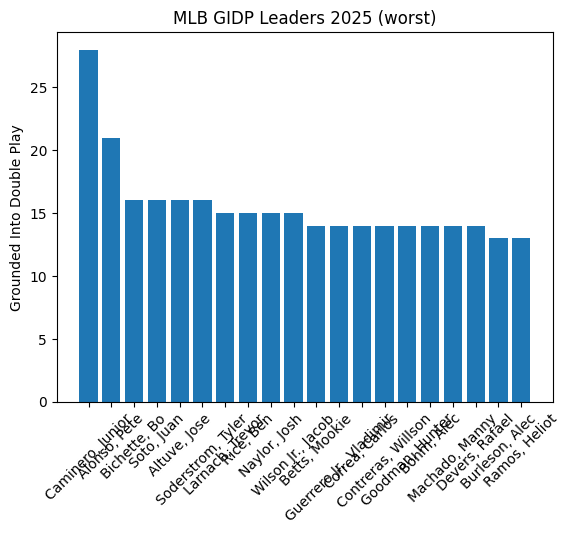

In [16]:
Top20 = batter_df.sort_values("b_gnd_into_dp",ascending=False)
Top20 = Top20.head(20)
plt.bar(Top20["last_name, first_name"], Top20["b_gnd_into_dp"])
plt.ylabel("Grounded Into Double Play")
plt.title("MLB GIDP Leaders 2025 (worst)")
plt.xticks(rotation=45)
plt.show()

## Fewest Ground Into Double Plays (GIDP)

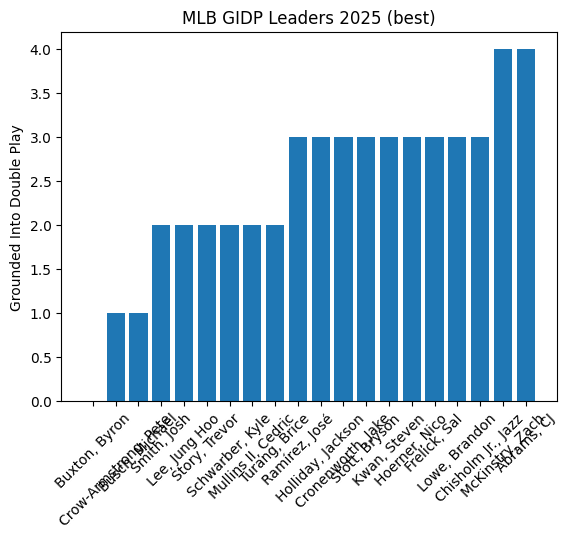

In [17]:
Top20 = batter_df.sort_values("b_gnd_into_dp",ascending=True)
Top20 = Top20.head(20)
plt.bar(Top20["last_name, first_name"], Top20["b_gnd_into_dp"])
plt.ylabel("Grounded Into Double Play")
plt.title("MLB GIDP Leaders 2025 (best)")
plt.xticks(rotation=45)
plt.show()

## On Base Percentage (OBP) Leaders

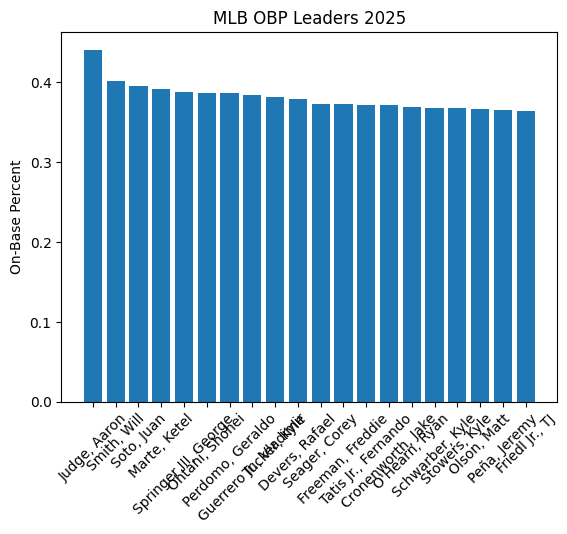

In [18]:
Top20 = batter_df.sort_values("on_base_percent",ascending=False)

Top20 = Top20.head(20)

plt.bar(Top20["last_name, first_name"], Top20["on_base_percent"])

plt.ylabel("On-Base Percent")

plt.title("MLB OBP Leaders 2025")

plt.xticks(rotation=45)

plt.show()

##

## Give me an MLB Player

In [19]:
# StatsPlayer=input("Give me an MLB Player")
# print(batter_df[batter_df['last_name, first_name']==StatsPlayer])
# print(ranks.loc[StatsPlayer])

## On Base Plus Slugging (OPS) Leaders

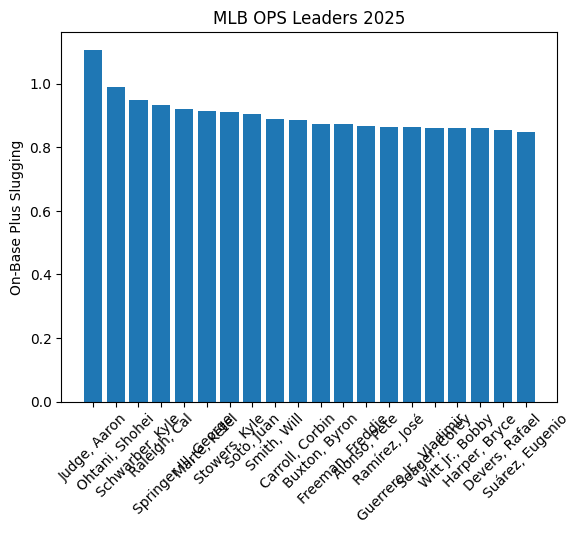

In [20]:
Top20 = batter_df.sort_values("on_base_plus_slg",ascending=False)

Top20 = Top20.head(20)

plt.bar(Top20["last_name, first_name"], Top20["on_base_plus_slg"])

plt.ylabel("On-Base Plus Slugging")

plt.title("MLB OPS Leaders 2025")

plt.xticks(rotation=45)

plt.show()

## Home Run (HR) Leaders

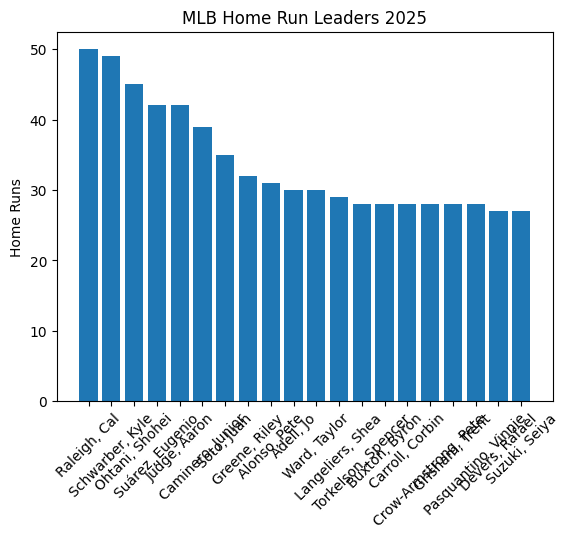

In [21]:
Top20 = batter_df.sort_values("home_run",ascending=False)

Top20=Top20.head(20)

plt.bar(Top20["last_name, first_name"], Top20["home_run"])

plt.ylabel("Home Runs")

plt.title("MLB Home Run Leaders 2025")

plt.xticks(rotation=45)

plt.show()

## Stats for Top MLB Players

In [22]:
print_player(batter_df, "Judge, Aaron")

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
25,"Judge, Aaron",592450,42,0.321,0.441,1.107,12,4.050538


In [23]:
print_player(batter_df, "Ohtani, Shohei")

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
66,"Ohtani, Shohei",660271,45,0.276,0.387,0.99,6,0.0


In [24]:
print_player(batter_df, "Raleigh, Cal")

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
71,"Raleigh, Cal",663728,50,0.241,0.352,0.933,6,5.119952


In [25]:
print_player(batter_df, "Crow-Armstrong, Pete")

,"last_name, first_name",player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
9,"Crow-Armstrong, Pete",691718,28,0.252,0.291,0.789,1,20.055742


# 🌟 Rylan Player Score (RPS) for Batters

In [26]:
# Calculate RPS (Rylan's Player Score)
batter_df["rps"] = (
    (16.7 * batter_df['on_base_plus_slg']) +
    (0.4 * batter_df['home_run']) +
    (11 * batter_df['on_base_percent']) +
    (11 * batter_df['batting_avg']) +
    (-0.08 * batter_df['b_gnd_into_dp']) +
    (0.5 * batter_df['fielding_run_value'])
)

# Calculate RPS rank (1, 2, 3, ...)
batter_df["rps_rank"] = batter_df["rps"].rank(method="dense", ascending=False).astype(int)

# Get top N
rps_topN = batter_df.sort_values("rps", ascending=False)
rps_topN = rps_topN.head(30)

# Move rps and rps_rank columns to the beginning, right after the name
cols = rps_topN.columns.tolist()
cols.remove("rps")
cols.remove("rps_rank")
cols = [cols[0], "rps", "rps_rank"] + cols[1:]
rps_topN = rps_topN[cols]

rps_topN

,"last_name, first_name",rps,rps_rank,player_id,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
25,"Judge, Aaron",44.734169,1,592450,42,0.321,0.441,1.107,12,4.050538
71,"Raleigh, Cal",44.184076,2,663728,50,0.241,0.352,0.933,6,5.119952
125,"Schwarber, Kyle",42.036600,3,656941,49,0.247,0.368,0.948,2,0.000000
66,"Ohtani, Shohei",41.346000,4,660271,45,0.276,0.387,0.990,6,0.000000
9,"Crow-Armstrong, Pete",40.297171,5,691718,28,0.252,0.291,0.789,1,20.055742
128,"Witt Jr., Bobby",37.689589,6,677951,20,0.299,0.355,0.860,6,17.227178
43,"Carroll, Corbin",34.835242,7,682998,28,0.256,0.331,0.884,5,5.630885
44,"Buxton, Byron",34.438257,8,621439,28,0.270,0.332,0.874,0,4.040914
80,"Ramírez, José",34.259409,9,608070,26,0.285,0.360,0.864,3,5.151217
42,"Suárez, Eugenio",34.017843,10,553993,42,0.235,0.306,0.848,8,-4.509513


## Evaluating RPS for Batters



In [27]:
batter_master_list = [
    "Ohtani, Shohei",
    "Judge, Aaron",
    "Raleigh, Cal",
    "Schwarber, Kyle",
    "Crow-Armstrong, Pete",
    "Springer III, George",
    "Ramírez, José",
    "Soto, Juan",
    "Witt Jr., Bobby",
    "Kurtz, Nick"
    "Marte, Ketel",
    "Smith, Will",
    "Stowers, Kyle",
    "Guerrero Jr., Vladimir",
    "Alonso, Pete",
    "Buxton, Byron",
    "Freeman, Freddie",
    "Machado, Manny",
    "Carroll, Corbin",
    "Perdomo, Geraldo"
]

batter_master_list_df = pd.DataFrame(list(enumerate(batter_master_list)), columns=["master_rank", "last_name, first_name"])
batter_master_list_df["master_rank"] += 1

In [28]:
batter_eval_df = pd.merge(batter_df, batter_master_list_df, on="last_name, first_name", how="outer")

# Every player outside the master top 20 list gets master_rank 30
batter_eval_df["master_rank"] = batter_eval_df["master_rank"].fillna(30).astype(int)

# Calculate rank_diff (capping rps_rank to 30)
#Issue: NaN values, two names in one row
batter_eval_df["rank_diff"] = (batter_eval_df["rps_rank"].clip(upper=30) - batter_eval_df["master_rank"]).dropna().abs().astype(int)

# Reorder master_rank and rank_diff so they are right after rps_rank
cols = batter_eval_df.columns.tolist()
cols.remove("rps")
cols.remove("rps_rank")
cols.remove("master_rank")
cols.remove("rank_diff")
cols = cols[:1] + ["rps", "rps_rank", "master_rank", "rank_diff"] + cols[3:]
batter_eval_df = batter_eval_df[cols]
batter_eval_df = batter_eval_df.sort_values(by="rank_diff", ascending=False)

batter_eval_df.head(30)

,"last_name, first_name",rps,rps_rank,master_rank,rank_diff,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp,fielding_run_value
125,"Soto, Juan",29.666350,39.0,8,22.0,0.254,0.395,0.903,16.0,-10.545500
132,"Suárez, Eugenio",34.017843,10.0,30,20.0,0.235,0.306,0.848,8.0,-4.509513
10,"Bellinger, Cody",33.987850,11.0,30,19.0,0.280,0.334,0.839,7.0,6.765100
122,"Smith, Will",24.752656,91.0,11,19.0,0.291,0.402,0.889,7.0,-7.113289
19,"Caminero, Junior",33.107646,12.0,30,18.0,0.256,0.299,0.830,28.0,-0.436708
112,"Rodríguez, Julio",33.070794,13.0,30,17.0,0.264,0.317,0.779,13.0,8.620987
52,"Guerrero Jr., Vladimir",28.765961,47.0,13,17.0,0.288,0.384,0.863,14.0,-0.636278
4,"Alonso, Pete",29.051135,45.0,14,16.0,0.271,0.350,0.868,21.0,-5.990930
95,"Pages, Andy",32.964875,14.0,30,16.0,0.275,0.318,0.782,5.0,9.164950
135,"Tatis Jr., Fernando",32.429529,15.0,30,15.0,0.266,0.372,0.805,5.0,10.336058


In [29]:
total_batter_rank_diff = batter_eval_df["rank_diff"].sum()
print("Total Batter RPS rank difference (lower is better):")
print(total_batter_rank_diff)

Total Batter RPS rank difference (lower is better):
345.0


# 🌟 Rylan's Player Score (RPS) for Pitchers

In [30]:
# Calculate RPS (Rylan's Player Score)
pitching_df["rps_1"] = (-35 * pitching_df['walk_hit_ip'])
pitching_df["rps_2"] = (4.9 * pitching_df['k_percent'])
pitching_df["rps_3"] = (-4 * pitching_df['bb_percent'])
pitching_df["rps_4"] = (-5 * pitching_df['babip'])
pitching_df["rps_5"] = (-5 * pitching_df['p_era'])
pitching_df["rps_6"] = (1.7 * pitching_df['p_gnd_into_dp'])
pitching_df["rps_7"] =  (-0.4 * pitching_df['barrel_batted_rate'])
pitching_df["rps_8"] = (-0.1 * pitching_df['hard_hit_percent'])

pitching_df["rps"] = sum(pitching_df[f"rps_{i}"] for i in range(1, 9)) / 83 * 33

# Calculate RPS rank (1, 2, 3, ...)
pitching_df["rps_rank"] = pitching_df["rps"].rank(method="dense", ascending=False).astype(int)

# Get top N
rps_topN = pitching_df.sort_values("rps", ascending=False)
rps_topN = rps_topN.head(30)

# Move rps and rps_rank columns to the beginning, right after the name
cols = rps_topN.columns.tolist()
cols.remove("rps")
cols.remove("rps_rank")
cols = [cols[0], "rps", "rps_rank"] + cols[1:]
rps_topN = rps_topN[cols]

rps_topN

,"last_name, first_name",rps,rps_rank,player_id,hit,innings_pitched,walk,k_percent,bb_percent,babip,...,hard_hit_percent,walk_hit_ip,rps_1,rps_2,rps_3,rps_4,rps_5,rps_6,rps_7,rps_8
41,"Skubal, Tarik",41.722198,1,669373,124,166.000000,27,32.8,4.1,0.275,...,33.5,0.909639,-31.837349,160.72,-16.4,-1.375,-11.40,11.9,-3.32,-3.35
2,"Wheeler, Zack",41.291977,2,554430,107,149.666667,33,33.3,5.6,0.267,...,34.1,0.935412,-32.739421,163.17,-22.4,-1.335,-13.55,17.0,-2.88,-3.41
34,"Skenes, Paul",35.712221,3,694973,121,167.000000,38,28.6,5.8,0.269,...,39.2,0.952096,-33.323353,140.14,-23.2,-1.345,-10.25,23.8,-2.08,-3.92
61,"Eovaldi, Nathan",34.920514,4,543135,90,130.000000,21,26.0,4.2,0.245,...,38.5,0.853846,-29.884615,127.40,-16.8,-1.225,-8.65,23.8,-2.96,-3.85
44,"Crochet, Garrett",34.184285,5,676979,141,172.333333,42,31.1,6.1,0.303,...,37.5,1.061896,-37.166344,152.39,-24.4,-1.515,-12.00,15.3,-2.88,-3.75
45,"Brown, Hunter",33.944745,6,686613,114,155.666667,49,28.8,7.7,0.263,...,32.1,1.047109,-36.648822,141.12,-30.8,-1.315,-11.85,30.6,-2.52,-3.21
85,"Webb, Logan",29.372999,7,657277,173,173.666667,37,26.1,5.2,0.342,...,41.0,1.209213,-42.322457,127.89,-20.8,-1.710,-15.80,34.0,-3.28,-4.10
46,"Sánchez, Cristopher",28.486692,8,650911,149,169.333333,41,26.3,6.0,0.310,...,40.6,1.122047,-39.271654,128.87,-24.0,-1.550,-13.30,27.2,-2.24,-4.06
72,"Ryan, Joe",28.269481,9,657746,120,148.000000,30,28.3,4.9,0.267,...,42.2,1.013514,-35.472973,138.67,-19.6,-1.335,-16.10,13.6,-4.44,-4.22
19,"Woo, Bryan",27.031992,10,693433,126,164.666667,31,25.6,4.8,0.244,...,41.3,0.953441,-33.370445,125.44,-19.2,-1.220,-14.75,18.7,-3.48,-4.13


## Evaluating RPS for Pitchers

In [31]:
pitcher_master_list = [
    "Skubal, Tarik",
    "Skenes, Paul",
    "Crochet, Garrett",
    "Yamamoto, Yoshinobu",
    "Brown, Hunter",
    "Peralta, Freddy",
    "Sánchez, Cristopher",
    "Wheeler, Zack",
    "Webb, Logan",
    "deGrom, Jacob",
    "Woo, Bryan",
    "Fried, Max",
    "Pivetta, Nick",
    "Boyd, Matthew",
    "Ray, Robbie",
    "Ryan, Joe",
    "Valdez, Framber",
    "Eovaldi, Nathan",
    "Rodón, Carlos",
    "Lodolo, Nick",
]
pitcher_master_list_df = pd.DataFrame(list(enumerate(pitcher_master_list)), columns=["master_rank", "last_name, first_name"])
pitcher_master_list_df["master_rank"] += 1

In [32]:
pitching_eval_df = pd.merge(pitching_df, pitcher_master_list_df, on="last_name, first_name", how="outer")

# Every player outside the master top 20 list gets master_rank 30
pitching_eval_df["master_rank"] = pitching_eval_df["master_rank"].fillna(30).astype(int)

pitching_eval_df

,"last_name, first_name",player_id,hit,innings_pitched,walk,k_percent,bb_percent,babip,p_era,p_gnd_into_dp,...,rps_2,rps_3,rps_4,rps_5,rps_6,rps_7,rps_8,rps,rps_rank,master_rank
0,"Abbott, Andrew",671096,116,139.000000,39,22.1,6.9,0.264,2.65,10,...,108.29,-27.6,-1.320,-13.25,17.0,-3.20,-3.30,14.945908,33,30
1,"Alcantara, Sandy",645261,143,141.000000,52,18.6,8.1,0.284,5.87,11,...,91.14,-32.4,-1.420,-29.35,18.7,-3.48,-4.46,-3.846391,91,30
2,"Allen, Logan",671106,136,134.333333,57,18.0,9.8,0.299,4.42,12,...,88.20,-39.2,-1.495,-22.10,20.4,-3.84,-3.76,-4.803035,94,30
3,"Anderson, Tyler",542881,135,136.333333,57,17.4,9.5,0.263,4.56,7,...,85.26,-38.0,-1.315,-22.80,11.9,-4.40,-3.66,-8.868632,103,30
4,"Bassitt, Chris",605135,156,150.000000,44,22.8,6.8,0.318,4.14,14,...,111.72,-27.2,-1.590,-20.70,23.8,-3.40,-3.57,12.879277,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,"Wheeler, Zack",554430,107,149.666667,33,33.3,5.6,0.267,2.71,10,...,163.17,-22.4,-1.335,-13.55,17.0,-2.88,-3.41,41.291977,2,8
107,"Williams, Gavin",668909,112,143.666667,73,23.6,12.0,0.251,3.26,10,...,115.64,-48.0,-1.255,-16.30,17.0,-3.52,-4.26,5.659856,57,30
108,"Woo, Bryan",693433,126,164.666667,31,25.6,4.8,0.244,2.95,11,...,125.44,-19.2,-1.220,-14.75,18.7,-3.48,-4.13,27.031992,10,11
109,"Yamamoto, Yoshinobu",808967,106,139.666667,48,28.4,8.2,0.263,2.90,9,...,139.16,-32.8,-1.315,-14.50,15.3,-2.16,-4.01,24.286058,13,4


In [33]:
# Calculate rank_diff (capping rps_rank to 30)
pitching_eval_df["rank_diff"] = (pitching_eval_df["rps_rank"].clip(upper=30) - pitching_eval_df["master_rank"]).abs().astype(int)

# Re-order master_rank and rank_diff so they are right after rps_rank
cols = pitching_eval_df.columns.tolist()
cols.remove("rps")
cols.remove("rps_rank")
cols.remove("master_rank")
cols.remove("rank_diff")
cols = cols[:1] + ["rps", "rps_rank", "master_rank", "rank_diff"] + cols[3:]
pitching_eval_df = pitching_eval_df[cols]
pitching_eval_df = pitching_eval_df.sort_values(by="rank_diff", ascending=False)

pitching_eval_df.head(30)

,"last_name, first_name",rps,rps_rank,master_rank,rank_diff,innings_pitched,walk,k_percent,bb_percent,babip,...,hard_hit_percent,walk_hit_ip,rps_1,rps_2,rps_3,rps_4,rps_5,rps_6,rps_7,rps_8
84,"Schwellenbach, Spencer",25.115639,12,30,18,110.666667,18,24.9,4.1,0.260,...,41.5,0.966867,-33.840361,122.01,-16.4,-1.300,-15.45,15.3,-3.00,-4.15
35,"Gray, Sonny",24.063491,14,30,16,152.333333,28,26.8,4.5,0.326,...,38.8,1.181619,-41.356674,131.32,-18.0,-1.630,-20.95,18.7,-3.68,-3.88
30,"Fried, Max",17.691225,27,12,15,162.000000,42,23.1,6.3,0.279,...,37.7,1.111111,-38.888889,113.19,-25.2,-1.395,-15.30,18.7,-2.84,-3.77
77,"Rasmussen, Drew",23.912991,15,30,15,129.666667,28,22.6,5.6,0.253,...,42.9,0.979434,-34.280206,110.74,-22.4,-1.265,-13.20,27.2,-2.36,-4.29
78,"Ray, Robbie",11.398043,39,15,15,164.000000,64,24.3,9.5,0.256,...,44.6,1.164634,-40.762195,119.07,-38.0,-1.280,-15.90,13.6,-3.60,-4.46
25,"Eovaldi, Nathan",34.920514,4,18,14,130.000000,21,26.0,4.2,0.245,...,38.5,0.853846,-29.884615,127.40,-16.8,-1.225,-8.65,23.8,-2.96,-3.85
70,"Peralta, Freddy",19.598682,20,6,14,153.666667,58,26.7,9.2,0.243,...,32.8,1.073753,-37.581345,130.83,-36.8,-1.215,-12.90,13.6,-3.36,-3.28
13,"Bubic, Kris",19.977816,19,30,11,116.333333,39,24.4,8.2,0.295,...,39.3,1.177650,-41.217765,119.56,-32.8,-1.475,-12.75,25.5,-2.64,-3.93
109,"Yamamoto, Yoshinobu",24.286058,13,4,9,139.666667,48,28.4,8.2,0.263,...,40.1,1.102625,-38.591885,139.16,-32.8,-1.315,-14.50,15.3,-2.16,-4.01
69,"Pepiot, Ryan",18.902855,22,30,8,158.000000,55,24.4,8.6,0.256,...,43.2,1.151899,-40.316456,119.56,-34.4,-1.280,-18.50,30.6,-3.80,-4.32


In [156]:
total_pitching_rank_diff = pitching_eval_df["rank_diff"].sum()
print("Total Pitching RPS rank difference (lower is better):")
print(total_pitching_rank_diff)

Total Pitching RPS rank difference (lower is better):
191


# 📈Graphs


In [157]:
print_player(pitching_eval_df,"Webb, Logan")

,"last_name, first_name",rps,rps_rank,master_rank,rank_diff,innings_pitched,walk,k_percent,bb_percent,babip,...,hard_hit_percent,walk_hit_ip,rps_1,rps_2,rps_3,rps_4,rps_5,rps_6,rps_7,rps_8
105,"Webb, Logan",29.372999,7,9,2,173.666667,37,26.1,5.2,0.342,...,41.0,1.209213,-42.322457,127.89,-20.8,-1.71,-15.8,34.0,-3.28,-4.1


In [158]:
pitching_eval_df.columns

Index(['last_name, first_name', 'rps', 'rps_rank', 'master_rank', 'rank_diff', 'innings_pitched', 'walk', 'k_percent', 'bb_percent', 'babip', 'p_era', 'p_gnd_into_dp',
       'barrel_batted_rate', 'hard_hit_percent', 'walk_hit_ip', 'rps_1', 'rps_2', 'rps_3', 'rps_4', 'rps_5', 'rps_6', 'rps_7', 'rps_8'],
      dtype='object')

Text(0, 0.5, 'ERA')

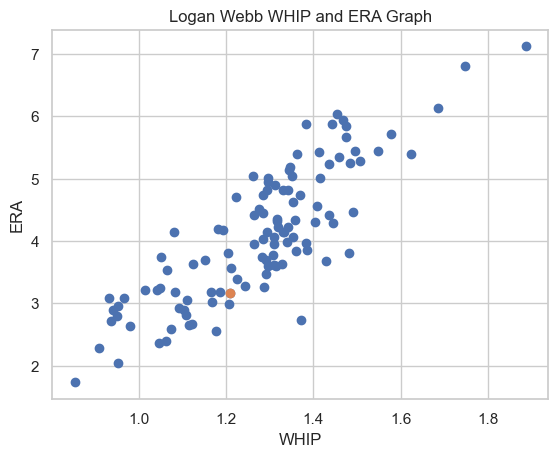

In [159]:
player=print_player(pitching_eval_df,"Webb, Logan")
plt.scatter(pitching_eval_df["walk_hit_ip"],pitching_eval_df["p_era"])
plt.scatter(player["walk_hit_ip"],player["p_era"])
plt.title("Logan Webb WHIP and ERA Graph")
plt.xlabel("WHIP")
plt.ylabel("ERA")

Text(0, 0.5, 'ERA')

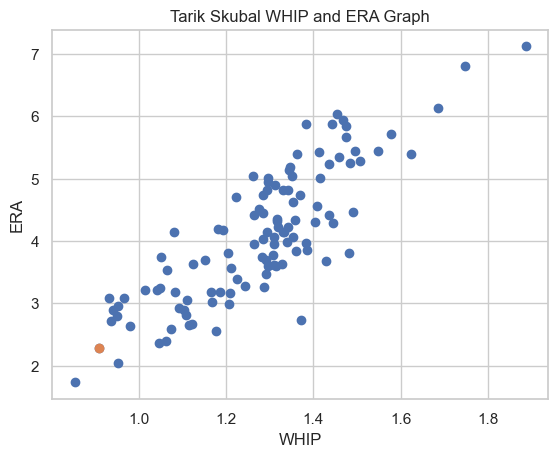

In [160]:
player=print_player(df=pitching_eval_df,full_name="Skubal, Tarik")
plt.scatter(pitching_eval_df["walk_hit_ip"],pitching_eval_df["p_era"])
plt.scatter(player["walk_hit_ip"],player["p_era"])
plt.title("Tarik Skubal WHIP and ERA Graph")
plt.xlabel("WHIP")
plt.ylabel("ERA")

In [ ]:
player=print_player(pitching_eval_df,"Skenes, Paul")
plt.scatter(pitching_eval_df["walk_hit_ip"],pitching_eval_df["p_era"])
plt.scatter(player["walk_hit_ip"],player["p_era"])
plt.title("Paul Skenes WHIP and ERA Graph")
plt.xlabel("WHIP")
plt.ylabel("ERA")

In [ ]:
player=print_player(pitching_eval_df,"Wheeler, Zack")
plt.scatter(pitching_eval_df["walk_hit_ip"],pitching_eval_df["p_era"])
plt.scatter(player["walk_hit_ip"],player["p_era"])
plt.title("Zack Wheeler WHIP and ERA Graph")
plt.xlabel("WHIP")
plt.ylabel("ERA")

In [ ]:
player=print_player(pitching_eval_df,"Yamamoto, Yoshinobu")
plt.scatter(pitching_eval_df["walk_hit_ip"],pitching_eval_df["p_era"])
plt.scatter(player["walk_hit_ip"],player["p_era"])
plt.title("Yoshinobu Yamamoto WHIP and ERA Graph")
plt.xlabel("WHIP")
plt.ylabel("ERA")

In [161]:
def player_radar_from_csv(
    df: pd.DataFrame,
    player_name: str,
    name_col: str = "Player",
    stats: list[str] | None = None,   # e.g. ["HR","RBI","R","AVG","OBP","SLG","OPS"]
    normalize: bool = False,          # if True, min-max normalize each stat across all players
    invert=None,
    ax=None
):
    """
    Plot a radar (spider) chart for a single player's raw stat values (no rankings).
    Parameters
    ----------
    csv_path : str
        Path to the CSV.
    player_name : str
        Exact value in the name column for the player.
    name_col : str
        Column containing player names.
    stats : list[str] | None
        The stat columns to include. If None, auto-select all numeric columns (excluding name_col).
    normalize : bool
        If True, scales each stat to [0,1] using min-max across the dataset (per column).
        Useful when stats have very different scales (e.g., HR vs AVG).
    """
    if name_col not in df.columns:
        raise ValueError(f"'{name_col}' not found in CSV. Available columns: {df.columns.tolist()}")
    if stats is None:
        # auto-detect numeric stat columns (excluding the name column)
        numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
        stats = [c for c in numeric_cols if c != name_col]
    # ensure requested stat columns exist
    missing = [c for c in stats if c not in df.columns]
    if missing:
        raise ValueError(f"These stat columns were not found: {missing}")
    # ensure player exists
    if player_name not in df[name_col].values:
        # small hint if there's a typo
        possible = df[name_col].astype(str)
        suggestions = possible[possible.str.contains(player_name[:3], case=False, na=False)].unique()[:5]
        raise ValueError(f"Player '{player_name}' not found. Suggestions: {list(suggestions)}")
        # slice and set index to names for easy access
    sub = df[[name_col] + stats].copy().set_index(name_col)
    if invert:
          for col in invert:
            sub[col]=sub[col].max()-sub[col]
    # convert to numeric (coerce errors to NaN) and handle missing
    for c in stats:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
    if sub[stats].isna().any().any():
        # you can choose to fill or drop; here we fill NaNs with column medians
        sub[stats] = sub[stats].apply(lambda s: s.fillna(s.median()))
    # get the player's raw values
    values_raw = sub.loc[player_name, stats].astype(float).values
    # optional normalization to [0,1] per stat across all players
    if normalize:
        col_min = sub[stats].min().values
        col_max = sub[stats].max().values
        span = np.where((col_max - col_min) == 0, 1.0, (col_max - col_min))
        values = (values_raw - col_min) / span
        radial_label = "Scaled value (0–1)"
        radial_limits = (0, 1)

    else:
        values = values_raw
        radial_label = "Value"
        # set a sensible radial limit: 0 to a bit above max
        vmax = float(np.max(values)) if len(values) else 1.0
        radial_limits = (0, vmax * 1.1 if vmax > 0 else 1.0)
    # Build radar chart
    labels = stats
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    vals = values.tolist() + values[:1].tolist()
    if ax is None:
      fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, vals, linewidth=2, marker="o", label=player_name)
    ax.fill(angles, vals, alpha=0.2)
    # labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(*radial_limits)
    ax.set_rlabel_position(90)
    ax.set_ylabel(radial_label, labelpad=15)
    plt.title(f"{player_name} — Stats Radar", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.1))
    plt.tight_layout()
    plt.show()

In [ ]:
stats=["walk_hit_ip","p_era","k_percent","rps","master_rank"]
invert=["p_era","walk_hit_ip","master_rank"]

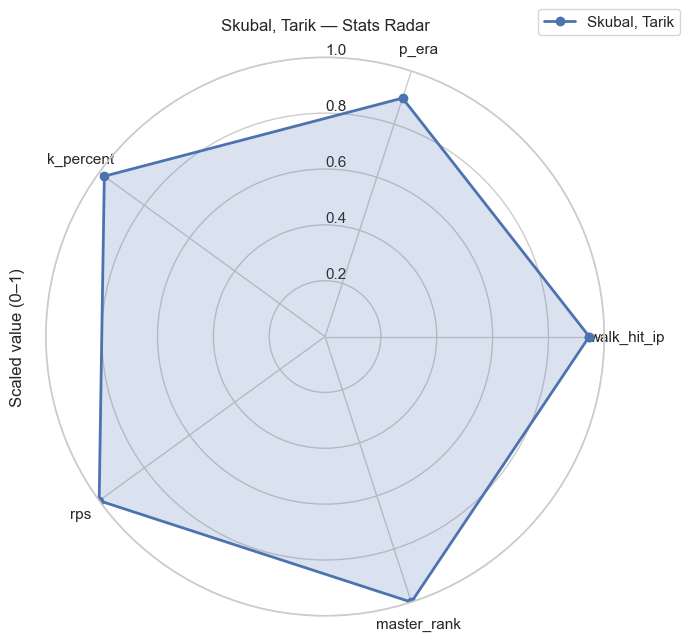

In [162]:
player_radar_from_csv(pitching_eval_df,"Skubal, Tarik","last_name, first_name",stats,True,invert=invert)

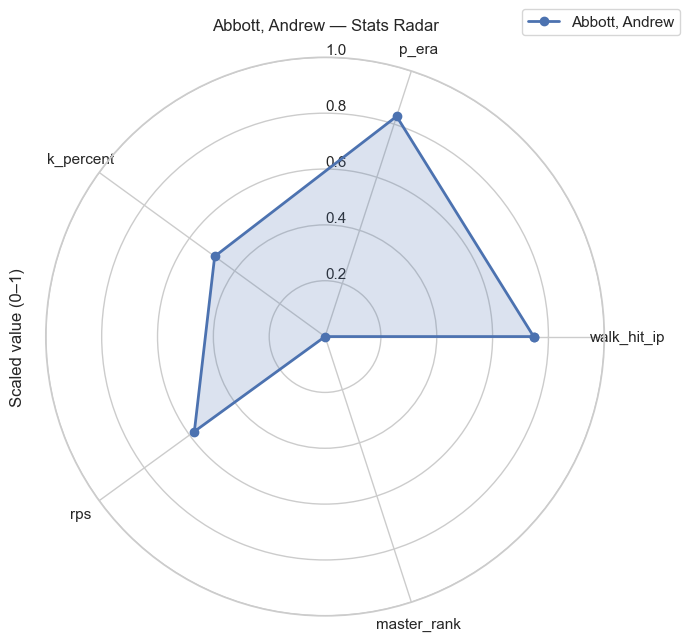

In [163]:
player_radar_from_csv(pitching_eval_df,"Abbott, Andrew","last_name, first_name",stats,True,invert=invert)

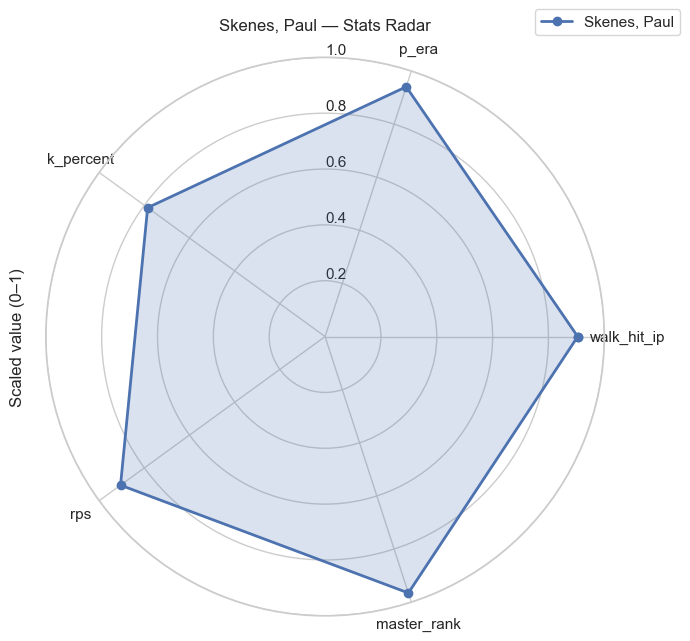

(None,)

In [164]:
player_radar_from_csv(pitching_eval_df,"Skenes, Paul","last_name, first_name",stats,True,invert=invert),

In [ ]:
player_radar_from_csv(pitching_eval_df,"Webb, Logan","last_name, first_name",stats,True,invert=invert),

In [ ]:
player_radar_from_csv(pitching_eval_df,"Wheeler, Zack","last_name, first_name",stats,True,invert=invert),

In [ ]:
player_radar_from_csv(pitching_eval_df,"Yamamoto, Yoshinobu","last_name, first_name",stats,True,invert=invert),

In [ ]:
player_radar_from_csv(pitching_eval_df,"Crochet, Garrett","last_name, first_name",stats,True,invert=invert)

In [ ]:
player_radar_from_csv(pitching_eval_df,"Peralta, Freddy","last_name, first_name",stats,True,invert=invert)

In [ ]:
player_radar_from_csv(pitching_eval_df,"Ray, Robbie","last_name, first_name",stats,True,invert=invert)

# ⚾️Fantasy MLB Team 2025


In [ ]:
#Positions: Starting Pitcher(SP), Relief Pitcher(RP), Catcher(C), First Baseman(1B), Second Baseman(2B), Shortstop(SS), Third Baseman(3B), Left Fielder(LF), Center fielder(CF), Right Fielder(RF), Designated Hitter(DH)
#Players: SP Tarik Skubal DET, SP Paul Skenes PIT, SP Garrett Crochet BOS, SP Yoshinobu Yamamoto LAD, SP Hunter Brown HOU, RP Aroldis Chapman BOS, RP Roki Sasaki LAD, RP Edwin Díaz NYM, C Cal Raleigh SEA, 1B Nick Kurtz OAK, 2B Ketel Marte ARI, SS Bobby Witt Jr. KC, 3B José Ramírez CLE, LF Kyle Schwarber PHI, CF Pete-Crow Armstrong CHI, RF Aaron Judge NYY, DH Shohei Ohtani LAD


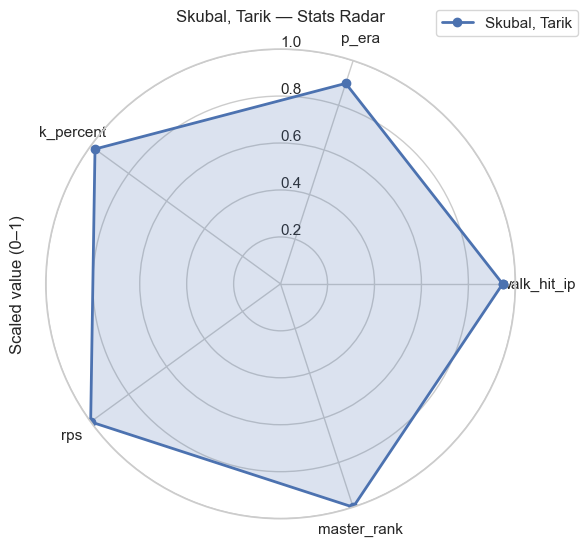

In [165]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)

player_radar_from_csv(
    pitching_eval_df,
    "Skubal, Tarik",
    "last_name, first_name",
    stats,
    True,
    invert=invert,
    ax=ax
)

plt.show()

In [ ]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)  # normal axes for image
ax2 = fig.add_subplot(1, 2, 2, polar=True)  # polar axes for radar
image=plt.imread("Paul Skenes.webp")
ax1.imshow(image)
ax1.axis("off")
player_radar_from_csv(pitching_eval_df,"Skenes, Paul","last_name, first_name",stats,True,invert=invert,ax=ax2)

In [ ]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)  # normal axes for image
ax2 = fig.add_subplot(1, 2, 2, polar=True)  # polar axes for radar
image=plt.imread("Garrett Crochet.jpg")
ax1.imshow(image)
ax1.axis("off")
player_radar_from_csv(pitching_eval_df,"Crochet, Garrett","last_name, first_name",stats,True,invert=invert,ax=ax2)

In [ ]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)  # normal axes for image
ax2 = fig.add_subplot(1, 2, 2, polar=True)  # polar axes for radar
image=plt.imread("Yoshinobu Yamamoto.webp")
ax1.imshow(image)
ax1.axis("off")
player_radar_from_csv(pitching_eval_df,"Yamamoto, Yoshinobu","last_name, first_name",stats,True,invert=invert,ax=ax2)

In [ ]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)  # normal axes for image
ax2 = fig.add_subplot(1, 2, 2, polar=True)  # polar axes for radar
image=plt.imread("Hunter Brown.webp")
ax1.imshow(image)
ax1.axis("off")
player_radar_from_csv(pitching_eval_df,"Brown, Hunter","last_name, first_name",stats,True,invert=invert,ax=ax2)

# Team Stats Analysis

In [166]:
import pandas as pd
from pybaseball import team_batting, team_pitching

YEAR = 2025

bat = team_batting(YEAR)
pit = team_pitching(YEAR)

In [167]:
bat.head()

,teamIDfg,Season,Team,Age,G,AB,PA,H,1B,2B,...,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR
0,9,2025,NYY,30,2401,5471,6235,1371,822,255,...,118.1,1879,0.461,4078,0.166,0.276,0.247,0.460,0.340,34.5
1,22,2025,LAD,30,2438,5481,6187,1384,862,257,...,120.0,1767,0.421,4198,0.167,0.277,0.251,0.447,0.335,28.9
2,14,2025,TOR,29,2481,5507,6180,1461,963,294,...,120.4,1847,0.411,4496,0.157,0.251,0.260,0.429,0.331,31.5
3,26,2025,PHI,30,2300,5517,6166,1426,922,268,...,117.2,1803,0.425,4241,0.150,0.264,0.252,0.432,0.328,26.4
4,15,2025,ARI,29,2332,5480,6210,1377,848,277,...,119.6,1754,0.411,4268,0.170,0.273,0.246,0.425,0.326,26.0


In [168]:
pit.head()

,teamIDfg,Season,Team,Age,W,L,ERA,G,GS,CG,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
0,13,2025,TEX,31,81,81,3.49,685,162,2,...,107,94.0,104.0,104.0,101,102,103,NaN,NaN,NaN
1,23,2025,MIL,28,97,65,3.59,712,162,0,...,103,98.0,99.0,96.0,102,101,103,NaN,NaN,NaN
2,29,2025,SDP,29,90,72,3.64,739,162,2,...,99,106.0,100.0,99.0,103,100,103,NaN,NaN,NaN
3,5,2025,CLE,27,88,74,3.70,693,162,2,...,105,116.0,108.0,124.0,98,99,96,NaN,NaN,NaN
4,3,2025,BOS,29,89,73,3.72,698,162,2,...,109,102.0,104.0,109.0,102,100,101,NaN,NaN,NaN


In [169]:
# Standardize team column
bat["team"] = bat["Team"].str.upper()
pit["team"] = pit["Team"].str.upper()

print("Batting table shape:", bat.shape)
print("Pitching table shape:", pit.shape)


Batting table shape: (30, 320)
Pitching table shape: (30, 393)


In [170]:
# Merge Batting + Pitching Tables

team_stats = bat.merge(
    pit,
    on="team",
    how="inner",
    suffixes=("_bat", "_pit")
)

print("Combined team stats shape:", team_stats.shape)

display(team_stats.head())


Combined team stats shape: (30, 712)


,teamIDfg_bat,Season_bat,Team_bat,Age_bat,G_bat,AB,PA,H_bat,1B,2B,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
0,9,2025,NYY,30,2401,5471,6235,1371,822,255,...,106,101.0,94.0,92.0,103,98,102,NaN,NaN,NaN
1,22,2025,LAD,30,2438,5481,6187,1384,862,257,...,107,105.0,99.0,101.0,102,99,102,NaN,NaN,NaN
2,14,2025,TOR,29,2481,5507,6180,1461,963,294,...,93,101.0,98.0,98.0,99,99,98,NaN,NaN,NaN
3,26,2025,PHI,30,2300,5517,6166,1426,922,268,...,106,94.0,105.0,103.0,105,104,109,NaN,NaN,NaN
4,15,2025,ARI,29,2332,5480,6210,1377,848,277,...,100,101.0,99.0,98.0,97,101,98,NaN,NaN,NaN


In [171]:
# Identify Best Teams by Key Stats

print("\nTop 10 Teams by OPS")
display(
    team_stats.sort_values("OPS", ascending=False)[
        ["team","OPS"]
    ].head(10)
)

print("\nTop 10 Teams by OBP")
display(
    team_stats.sort_values("OBP", ascending=False)[
        ["team","OBP"]
    ].head(10)
)

print("\nTop 10 Teams by Home Runs")
display(
    team_stats.sort_values("HR_bat", ascending=False)[
        ["team","HR_bat"]
    ].head(10)
)

print("\nBest Pitching (Lowest ERA)")
display(
    team_stats.sort_values("ERA")[
        ["team","ERA"]
    ].head(10)
)

print("\nBest WHIP (Lower is better)")
display(
    team_stats.sort_values("WHIP")[
        ["team","WHIP"]
    ].head(10)
)



Top 10 Teams by OPS


,team,OPS
0,NYY,0.787
1,LAD,0.768
2,TOR,0.761
3,PHI,0.759
4,ARI,0.757
5,NYM,0.753
6,CHC,0.751
7,ATH,0.749
8,BOS,0.745
10,SEA,0.740



Top 10 Teams by OBP


,team,OBP
2,TOR,0.333
0,NYY,0.332
9,MIL,0.332
3,PHI,0.328
1,LAD,0.327
5,NYM,0.326
4,ARI,0.325
8,BOS,0.324
15,SDP,0.321
12,ATL,0.320



Top 10 Teams by Home Runs


,team,HR_bat
0,NYY,274
1,LAD,244
10,SEA,238
24,LAA,226
5,NYM,224
6,CHC,223
7,ATH,219
4,ARI,214
3,PHI,212
11,DET,198



Best Pitching (Lowest ERA)


,team,ERA
25,TEX,3.49
9,MIL,3.59
15,SDP,3.64
28,CLE,3.70
8,BOS,3.72
19,KCR,3.73
29,PIT,3.76
3,PHI,3.79
6,CHC,3.81
20,SFG,3.84



Best WHIP (Lower is better)


,team,WHIP
25,TEX,1.18
6,CHC,1.18
15,SDP,1.21
14,TBR,1.22
18,CIN,1.22
13,HOU,1.22
10,SEA,1.22
29,PIT,1.22
9,MIL,1.23
3,PHI,1.23



Top Teams by Overall Strength Score


,team,strength_score
0,NYY,87.710
1,LAD,78.285
10,SEA,76.235
6,CHC,72.110
5,NYM,71.735
24,LAA,69.580
7,ATH,68.970
3,PHI,68.890
4,ARI,68.110
11,DET,63.805


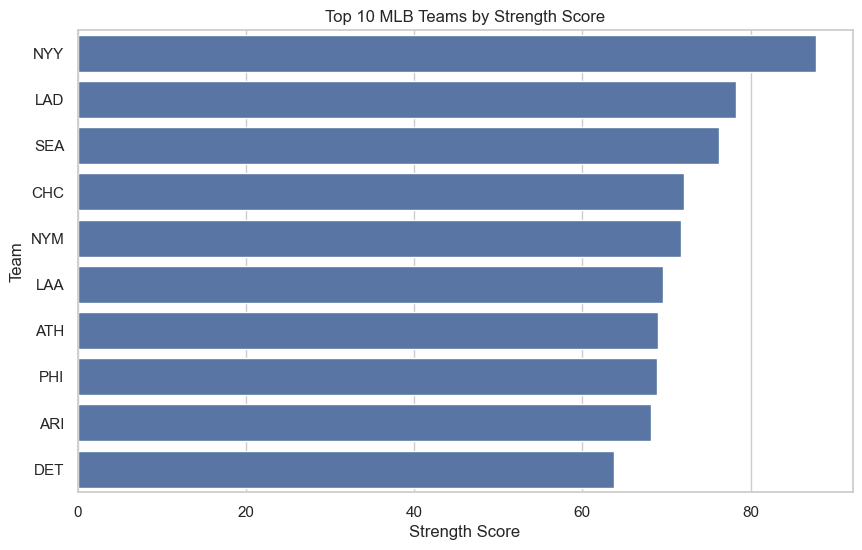

In [172]:
# Create Simple "Team Strength Score"

team_stats["strength_score"] = (
      15 * team_stats["OPS"]
    + 10 * team_stats["OBP"]
    + 0.3 * team_stats["HR_bat"]
    - 1.5 * team_stats["ERA"]
    - 3 * team_stats["WHIP"]
)

team_stats = team_stats.sort_values("strength_score", ascending=False)

print("\nTop Teams by Overall Strength Score")

display(
    team_stats[["team","strength_score"]].head(10)
)


# ------------------------------------------------------
# 6. Visualization: Top 10 Teams
# ------------------------------------------------------

plt.figure(figsize=(10,6))

top = team_stats.head(10)

sns.barplot(
    data=top,
    y="team",
    x="strength_score"
)

plt.title("Top 10 MLB Teams by Strength Score")
plt.xlabel("Strength Score")
plt.ylabel("Team")

plt.show()

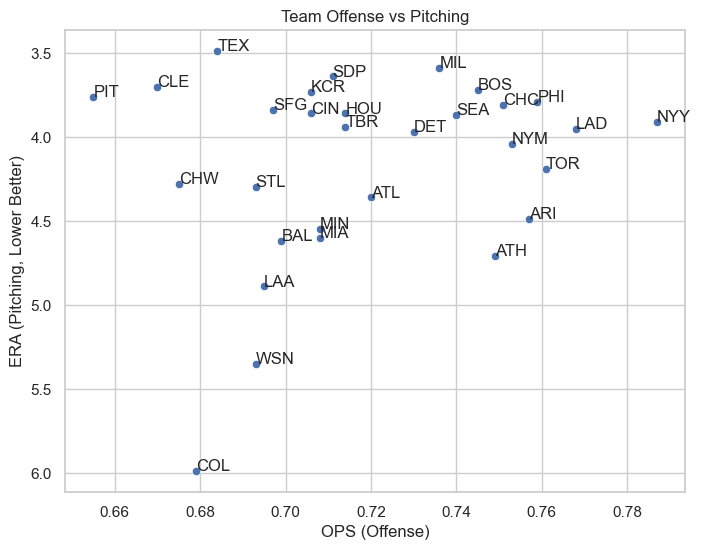

In [173]:
# Offense vs Pitching Scatter

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=team_stats,
    x="OPS",
    y="ERA"
)

for i,row in team_stats.iterrows():
    plt.text(row["OPS"], row["ERA"], row["team"])

plt.title("Team Offense vs Pitching")
plt.xlabel("OPS (Offense)")
plt.ylabel("ERA (Pitching, Lower Better)")

plt.gca().invert_yaxis()

plt.show()



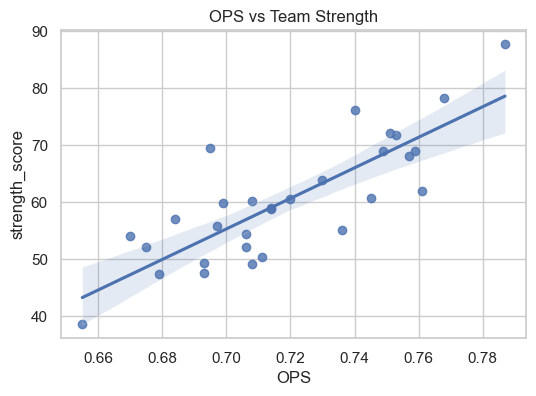

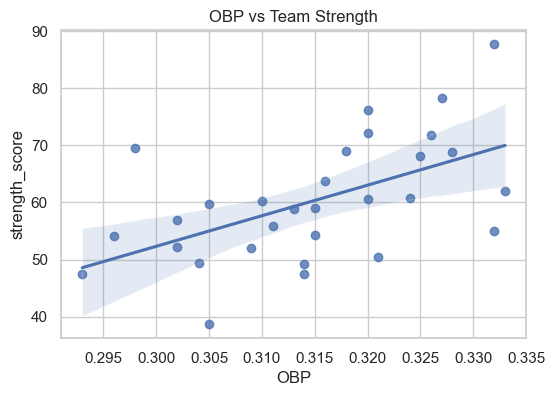

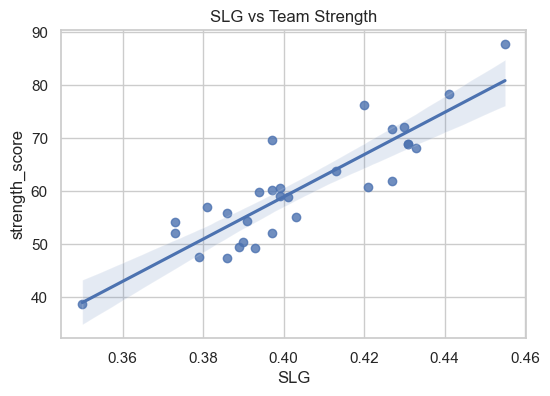

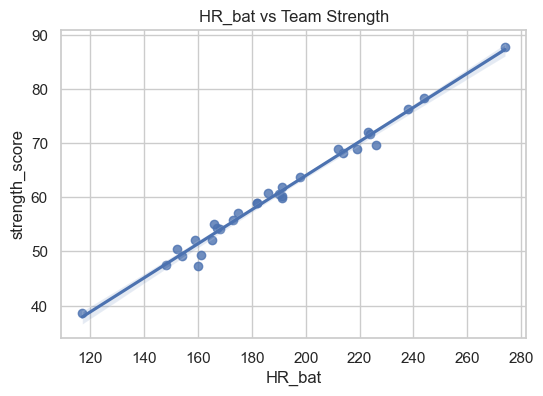

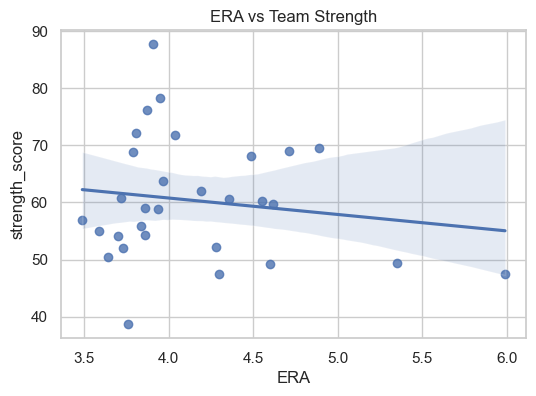

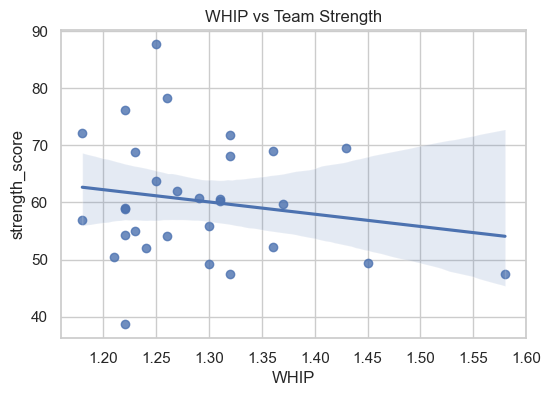

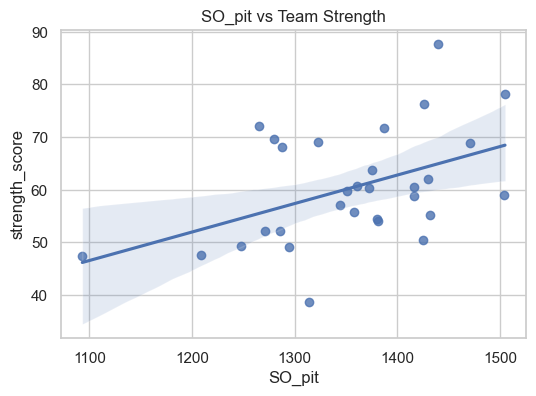

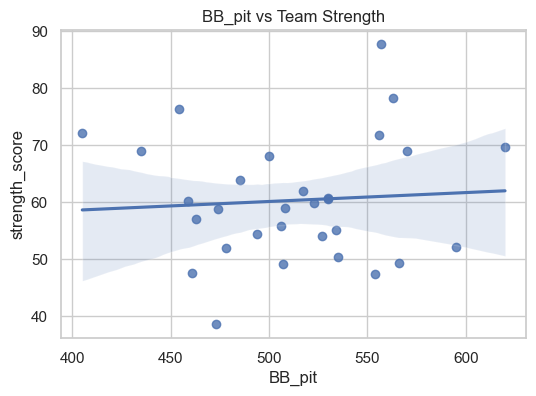


EDA Complete!


In [174]:
# Offensive Stats vs Team Strength

offense_stats = ["OPS","OBP","SLG","HR_bat"]

for stat in offense_stats:

    if stat not in team_stats.columns:
        continue

    plt.figure(figsize=(6,4))

    sns.regplot(
        data=team_stats,
        x=stat,
        y="strength_score"
    )

    plt.title(f"{stat} vs Team Strength")

    plt.show()


# ------------------------------------------------------
# 10. Pitching Stats vs Team Strength
# ------------------------------------------------------

pitch_stats = ["ERA","WHIP","SO_pit","BB_pit"]

for stat in pitch_stats:

    if stat not in team_stats.columns:
        continue

    plt.figure(figsize=(6,4))

    sns.regplot(
        data=team_stats,
        x=stat,
        y="strength_score"
    )

    plt.title(f"{stat} vs Team Strength")

    plt.show()


print("\nEDA Complete!")

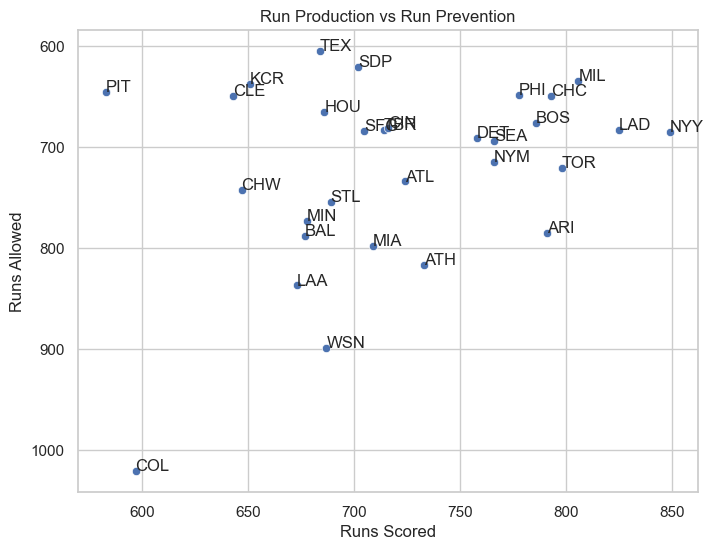

In [175]:
# Run production vs prevention

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=team_stats,
    x="R_bat",
    y="R_pit"
)

for _,row in team_stats.iterrows():
    plt.text(row["R_bat"], row["R_pit"], row["team"])

plt.title("Run Production vs Run Prevention")
plt.xlabel("Runs Scored")
plt.ylabel("Runs Allowed")

plt.gca().invert_yaxis()

plt.show()

In [176]:
# Expected Wins: Bill James Pythagorean Expected Wins 
team_stats["pyth_win_pct"] = (
    team_stats["R_bat"]**2 /
    (team_stats["R_bat"]**2 + team_stats["R_pit"]**2)
)

team_stats["expected_wins"] = team_stats["pyth_win_pct"] * 162

display(
    team_stats[["team","expected_wins"]]
    .sort_values("expected_wins", ascending=False)
    .head(10)
)

,team,expected_wins
9,MIL,100.077817
0,NYY,98.123707
6,CHC,97.017797
1,LAD,96.120569
3,PHI,95.646855
8,BOS,93.120171
25,TEX,90.891473
15,SDP,90.881328
2,TOR,89.190934
10,SEA,88.969659


Cluster averages:


,OPS,HR_bat,ERA,WHIP
cluster,,,,
0,0.699300,164.100000,3.741000,1.230000
1,0.696333,179.166667,4.540000,1.348333
2,0.761000,238.200000,3.866000,1.228000
3,0.686000,160.500000,5.670000,1.515000
4,0.745000,203.142857,4.211429,1.302857


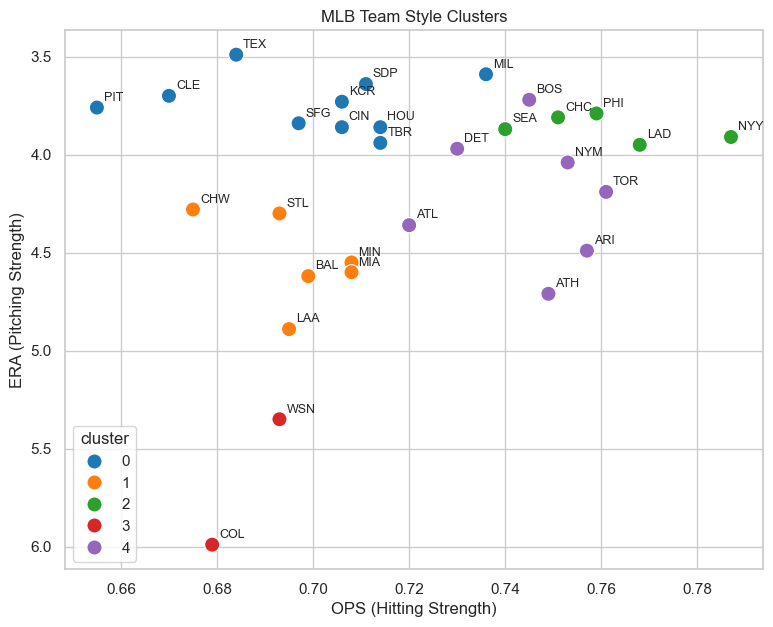

In [177]:
# Simple Team Clustering

from sklearn.cluster import KMeans

# Select simple features
features = team_stats[["OPS", "HR_bat", "ERA", "WHIP"]].copy()

# Optional but helpful: scale features so clustering works better
features = (features - features.mean()) / features.std()

# Fit KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=0, n_init=20)

team_stats["cluster"] = kmeans.fit_predict(features)

# Look at cluster averages

cluster_summary = team_stats.groupby("cluster")[["OPS","HR_bat", "ERA","WHIP"]].mean()

print("Cluster averages:")
display(cluster_summary)


# Plot clusters

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=team_stats,
    x="OPS",
    y="ERA",
    hue="cluster",
    palette="tab10",
    s=120
)

# Label each team
for _, row in team_stats.iterrows():
    plt.annotate(
        row["team"],
        (row["OPS"], row["ERA"]),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=9
    )

# ERA lower is better so flip axis
plt.gca().invert_yaxis()

plt.title("MLB Team Style Clusters")
plt.xlabel("OPS (Hitting Strength)")
plt.ylabel("ERA (Pitching Strength)")

plt.show()

# Player Stats

In [178]:
batting_df.head()

,"last_name, first_name",player_id,year,home_run,batting_avg,on_base_percent,on_base_plus_slg,b_gnd_into_dp
0,"Bell, Josh",605137,2025,16,0.230,0.325,0.711,13
1,"Polanco, Jorge",593871,2025,22,0.255,0.318,0.788,6
2,"Chourio, Jackson",694192,2025,18,0.278,0.313,0.794,10
3,"Wagaman, Eric",676572,2025,9,0.239,0.289,0.662,10
4,"Harris II, Michael",671739,2025,17,0.249,0.271,0.683,7


In [179]:
pitching_df.head()

,"last_name, first_name",player_id,hit,innings_pitched,walk,k_percent,bb_percent,babip,p_era,p_gnd_into_dp,...,rps_1,rps_2,rps_3,rps_4,rps_5,rps_6,rps_7,rps_8,rps,rps_rank
0,"Lugo, Seth",607625,133,145.333333,55,20.5,9.0,0.268,4.15,11,...,-45.275229,100.45,-36.0,-1.340,-20.75,18.7,-4.44,-4.52,2.713463,70
1,"Brown, Ben",676962,120,104.000000,30,25.1,6.5,0.348,5.88,7,...,-50.480769,122.99,-26.0,-1.740,-29.40,11.9,-4.48,-4.74,7.176200,53
2,"Wheeler, Zack",554430,107,149.666667,33,33.3,5.6,0.267,2.71,10,...,-32.739421,163.17,-22.4,-1.335,-13.55,17.0,-2.88,-3.41,41.291977,2
3,"Pfaadt, Brandon",694297,172,142.666667,33,18.8,5.1,0.327,5.24,9,...,-50.292056,92.12,-20.4,-1.635,-26.20,15.3,-4.56,-4.50,-0.066420,83
4,"Walker, Taijuan",592836,103,101.666667,32,16.8,7.4,0.285,3.63,8,...,-46.475410,82.32,-29.6,-1.425,-18.15,13.6,-2.60,-3.94,-2.493055,90


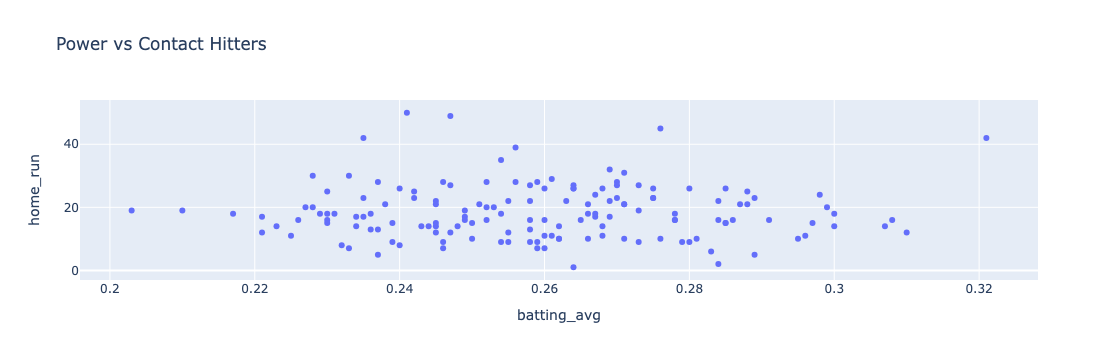

In [180]:
import plotly.express as px

fig = px.scatter(
    batter_df,
    x="batting_avg",
    y="home_run",
    hover_name="last_name, first_name",
    title="Power vs Contact Hitters",
)

fig.show()

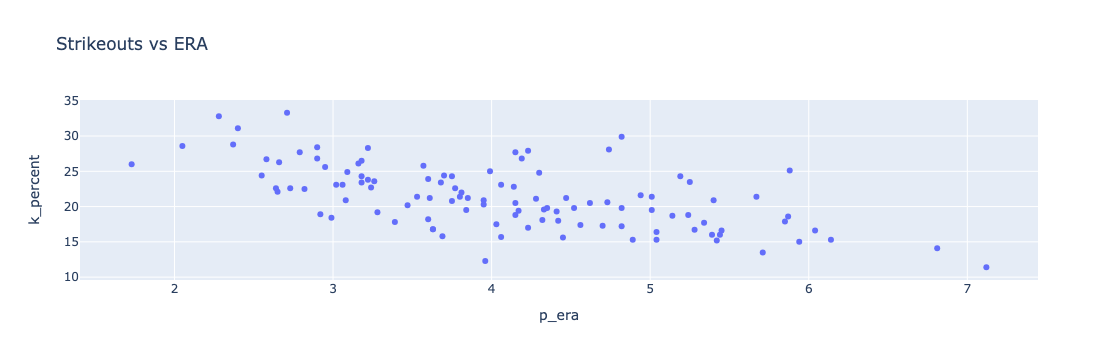

In [181]:
fig = px.scatter(
    pitching_df,
    x="p_era",
    y="k_percent",
    hover_name="last_name, first_name",
    title="Strikeouts vs ERA",
)

fig.show()

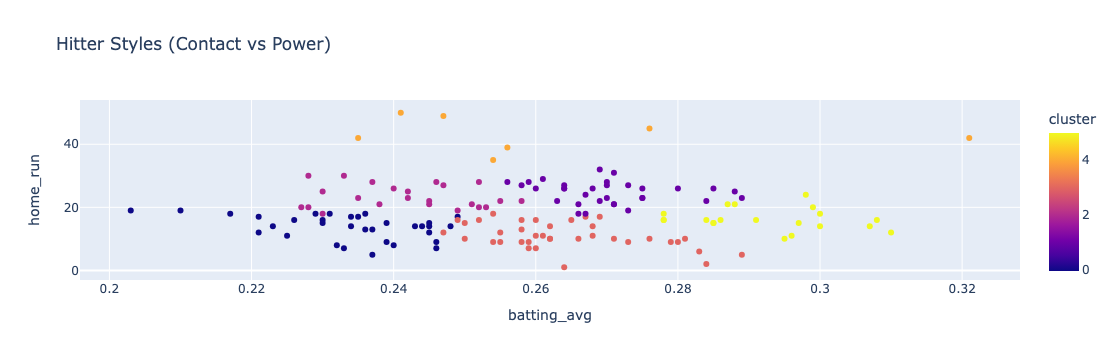

In [182]:
# Cluster Hitters by Style (Interactive)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features
cluster_features = batter_df[[
    "batting_avg",
    "home_run",
    "on_base_plus_slg"
]].dropna()

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(cluster_features)

# Run clustering
kmeans = KMeans(n_clusters=6, random_state=0)

batter_df.loc[cluster_features.index, "cluster"] = kmeans.fit_predict(X)

# -----------------------------------------------------
# Interactive Plot
# -----------------------------------------------------

fig = px.scatter(
    batter_df,
    x="batting_avg",
    y="home_run",
    color="cluster",
    hover_name="last_name, first_name",
    hover_data=[
        "batting_avg",
        "home_run",
        "on_base_percent",
        "on_base_plus_slg"
    ],
    title="Hitter Styles (Contact vs Power)"
)

fig.show()

# Similarity scores

In [184]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Select features for comparison
features = [
    "batting_avg",
    "home_run",
    "on_base_percent",
    "on_base_plus_slg",
    "b_gnd_into_dp"
]

# can add more!

player_data = batter_df[["last_name, first_name"] + features].dropna()

# Scale features
scaler = StandardScaler()

X = scaler.fit_transform(player_data[features])

# Find player
pete_idx = player_data[
    player_data["last_name, first_name"].str.contains("Guerrero", case=False)
].index[0]

# Compute distances
distances = euclidean_distances(X, X[pete_idx].reshape(1, -1)).flatten()

player_data["distance"] = distances

# Sort by similarity
similar_players = player_data.sort_values("distance")

# Remove player himself
similar_players = similar_players.iloc[1:11]

print("Players most similar to Vladdy:")
display(similar_players[[
    "last_name, first_name",
    "batting_avg",
    "home_run",
    "on_base_percent",
    "on_base_plus_slg",
    "b_gnd_into_dp",
    "distance"
]])

Players most similar to Vladdy:


,"last_name, first_name",batting_avg,home_run,on_base_percent,on_base_plus_slg,b_gnd_into_dp,distance
70,"Seager, Corey",0.271,21,0.373,0.860,13,0.888402
60,"Freeman, Freddie",0.300,18,0.373,0.872,11,1.043960
62,"Olson, Matt",0.271,21,0.367,0.827,12,1.171369
67,"Springer III, George",0.298,24,0.388,0.921,11,1.193267
47,"Marte, Ketel",0.289,23,0.392,0.915,10,1.226264
56,"O'Hearn, Ryan",0.278,16,0.369,0.823,11,1.261872
86,"Machado, Manny",0.287,21,0.348,0.816,14,1.370989
41,"Garcia, Maikel",0.297,15,0.360,0.831,11,1.420166
131,"Devers, Rafael",0.258,27,0.379,0.854,14,1.538948
102,"Naylor, Josh",0.284,16,0.347,0.791,15,1.699670


In [187]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Select pitching features

features = [
    "p_era",
    "k_percent",
    "bb_percent",
    "babip",
    "innings_pitched",
    "hit"
]

pitcher_data = pitching_df[["last_name, first_name"] + features].dropna()

# Standardize stats

scaler = StandardScaler()
X = scaler.fit_transform(pitcher_data[features])

# Find player

skubal_idx = pitcher_data[
    pitcher_data["last_name, first_name"].str.contains("Webb", case=False)
].index[0]

# Compute similarity

distances = euclidean_distances(X, X[skubal_idx].reshape(1, -1)).flatten()

pitcher_data["distance"] = distances

# Sort most similar

similar_pitchers = pitcher_data.sort_values("distance")

# remove player himself
similar_pitchers = similar_pitchers.iloc[1:11]

print("Pitchers most similar to Logan Webb:")

display(
    similar_pitchers[[
        "last_name, first_name",
        "p_era",
        "k_percent",
        "bb_percent",
        "innings_pitched",
        "distance"
    ]]
)

Pitchers most similar to Logan Webb:


,"last_name, first_name",p_era,k_percent,bb_percent,innings_pitched,distance
46,"Sánchez, Cristopher",2.66,26.3,6.0,169.333333,1.730210
55,"Gray, Sonny",4.19,26.8,4.5,152.333333,1.916434
56,"Bassitt, Chris",4.14,22.8,6.8,150.000000,2.237050
44,"Crochet, Garrett",2.40,31.1,6.1,172.333333,2.487061
57,"Luzardo, Jesús",4.23,27.9,8.0,149.000000,2.590493
110,"Castillo, Luis",3.75,20.8,6.7,151.333333,2.625233
20,"Kremer, Dean",4.52,19.8,6.2,155.333333,2.713969
17,"Keller, Mitch",4.35,19.8,6.6,151.000000,2.826166
31,"Fried, Max",3.06,23.1,6.3,162.000000,2.932313
93,"Kikuchi, Yusei",3.68,23.4,9.6,154.000000,2.940850


# PYBaseball player stats

In [188]:
# -----------------------------------------------------
# Import pybaseball
# -----------------------------------------------------
from pybaseball import batting_stats, pitching_stats
# -----------------------------------------------------
# Load Batter Stats
# -----------------------------------------------------
batter_df2 = batting_stats(2025)

# -----------------------------------------------------
# Load Pitcher Stats
# -----------------------------------------------------
pitcher_df2 = pitching_stats(2025)

# -----------------------------------------------------
# Quick check
# -----------------------------------------------------
print(batter_df2.head())
print(pitcher_df2.head())

     IDfg  Season             Name Team  Age    G   AB   PA    H   1B  ...  maxEV  HardHit  HardHit%  Events  CStr%   CSW%    xBA   xSLG  xwOBA  L-WAR
0   15640    2025      Aaron Judge  NYY   33  152  541  679  179   94  ...  118.1      226     0.582     388  0.150  0.292  0.300  0.708  0.459   10.2
3   21534    2025      Cal Raleigh  SEA   28  159  596  705  147   63  ...  114.7      204     0.496     411  0.106  0.254  0.231  0.547  0.371    9.2
22  25764    2025   Bobby Witt Jr.  KCR   25  157  623  687  184  108  ...  117.5      245     0.485     505  0.140  0.250  0.285  0.508  0.365    7.5
1   19755    2025    Shohei Ohtani  LAD   30  158  611  727  172   83  ...  120.0      250     0.584     428  0.147  0.289  0.274  0.649  0.425    7.2
8   22799    2025  Geraldo Perdomo  ARI   25  161  597  720  173  115  ...  108.2      170     0.319     533  0.214  0.254  0.278  0.424  0.356    6.9

[5 rows x 320 columns]
     IDfg  Season                Name Team  Age   W   L  WAR   ERA   G

In [189]:
print("Batter columns:")
print(list(batter_df2.columns))

print("\nPitcher columns:")
print(list(pitcher_df2.columns))

Batter columns:
['IDfg', 'Season', 'Name', 'Team', 'Age', 'G', 'AB', 'PA', 'H', '1B', '2B', '3B', 'HR', 'R', 'RBI', 'BB', 'IBB', 'SO', 'HBP', 'SF', 'SH', 'GDP', 'SB', 'CS', 'AVG', 'GB', 'FB', 'LD', 'IFFB', 'Pitches', 'Balls', 'Strikes', 'IFH', 'BU', 'BUH', 'BB%', 'K%', 'BB/K', 'OBP', 'SLG', 'OPS', 'ISO', 'BABIP', 'GB/FB', 'LD%', 'GB%', 'FB%', 'IFFB%', 'HR/FB', 'IFH%', 'BUH%', 'wOBA', 'wRAA', 'wRC', 'Bat', 'Fld', 'Rep', 'Pos', 'RAR', 'WAR', 'Dol', 'Spd', 'wRC+', 'WPA', '-WPA', '+WPA', 'RE24', 'REW', 'pLI', 'phLI', 'PH', 'WPA/LI', 'Clutch', 'FB% (Pitch)', 'FBv', 'SL%', 'SLv', 'CT%', 'CTv', 'CB%', 'CBv', 'CH%', 'CHv', 'SF%', 'SFv', 'KN%', 'KNv', 'XX%', 'PO%', 'wFB', 'wSL', 'wCT', 'wCB', 'wCH', 'wSF', 'wKN', 'wFB/C', 'wSL/C', 'wCT/C', 'wCB/C', 'wCH/C', 'wSF/C', 'wKN/C', 'O-Swing%', 'Z-Swing%', 'Swing%', 'O-Contact%', 'Z-Contact%', 'Contact%', 'Zone%', 'F-Strike%', 'SwStr%', 'BsR', 'FA% (sc)', 'FT% (sc)', 'FC% (sc)', 'FS% (sc)', 'FO% (sc)', 'SI% (sc)', 'SL% (sc)', 'CU% (sc)', 'KC% (sc)', 'E

In [ ]:
batter_df2 = batter_df2[[
    "Name",
    "Team",
    "PA",
    "AVG",
    "OBP",
    "SLG",
    "OPS",
    "ISO",
    "BABIP",
    "HR",
    "RBI",
    "BB",
    "SO",
    "BB%",
    "K%",
    "wOBA",
    "wRC+",
    "WAR",
    "Barrel%",
    "HardHit%",
    "EV"
]]

pitcher_df2 = pitcher_df2[[
    "Name",
    "Team",
    "IP",
    "ERA",
    "WHIP",
    "SO",
    "BB",
    "K%",
    "BB%",
    "K/9",
    "BB/9",
    "HR/9",
    "FIP",
    "xFIP",
    "SIERA",
    "WAR",
    "LOB%",
    "GB%",
    "HardHit%",
    "Barrel%",
    "EV"
]]

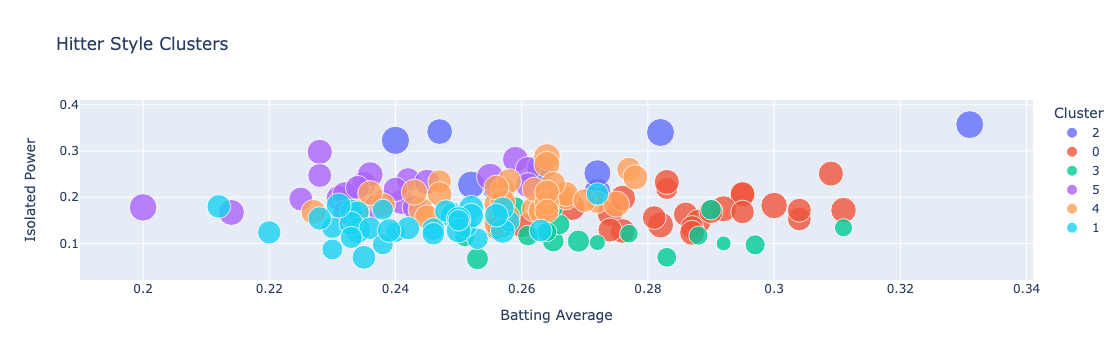

In [190]:
# Cluster Hitters by Style

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import pandas as pd

# Best available features from your trimmed batter_df2
feature_cols = [
    "AVG",
    "OBP",
    "ISO",
    "BB%",
    "K%",
    "BABIP",
    "HR",
    "Barrel%",
    "HardHit%",
    "EV"
]

# Build clustering dataframe
cluster_df2 = batter_df2[["Name", "Team", "PA"] + feature_cols].copy()

# Filter to qualified hitters
cluster_df2 = cluster_df2[cluster_df2["PA"] >= 200].dropna().copy()

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df2[feature_cols])

# Run clustering
kmeans2 = KMeans(n_clusters=6, random_state=0, n_init=20)
cluster_df2["cluster"] = kmeans2.fit_predict(X)

# Save labels back to batter_df2
batter_df2 = batter_df2.copy()
batter_df2["cluster"] = pd.NA
batter_df2.loc[cluster_df2.index, "cluster"] = cluster_df2["cluster"].astype(str)

# Plot dataframe
plot_df2 = cluster_df2.copy()
plot_df2["cluster"] = plot_df2["cluster"].astype(str)

# -----------------------------------------------------
# Interactive Plot
# -----------------------------------------------------

fig = px.scatter(
    plot_df2,
    x="AVG",
    y="ISO",
    color="cluster",
    size="HardHit%",
    hover_name="Name",
    hover_data={
        "Team": True,
        "PA": True,
        "AVG": ":.3f",
        "OBP": ":.3f",
        "ISO": ":.3f",
        "BB%": ":.1f",
        "K%": ":.1f",
        "BABIP": ":.3f",
        "HR": True,
        "Barrel%": ":.1f",
        "HardHit%": ":.1f",
        "EV": ":.1f",
        "cluster": True
    },
    title="Hitter Style Clusters",
    labels={
        "AVG": "Batting Average",
        "ISO": "Isolated Power",
        "HardHit%": "Hard-Hit %",
        "cluster": "Cluster"
    }
)

fig.update_traces(marker=dict(opacity=0.8))
fig.update_layout(legend_title_text="Cluster")
fig.show()

In [191]:
cluster_summary = cluster_df2.groupby("cluster")[feature_cols].mean().round(3)
print(cluster_summary)

           AVG    OBP    ISO    BB%     K%  BABIP      HR  Barrel%  HardHit%      EV
cluster                                                                             
0        0.285  0.357  0.171  0.094  0.167  0.319  19.423    0.090     0.456  90.796
1        0.243  0.306  0.143  0.076  0.195  0.280  15.417    0.076     0.403  89.017
2        0.268  0.378  0.282  0.143  0.253  0.306  44.444    0.191     0.557  93.811
3        0.272  0.341  0.122  0.085  0.134  0.302  11.105    0.035     0.292  86.642
4        0.258  0.315  0.201  0.069  0.237  0.301  26.394    0.116     0.461  90.830
5        0.237  0.330  0.218  0.112  0.255  0.277  28.500    0.138     0.477  91.218
